# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nuramenia
- **Email:** nuramenia5920@gmail.com
- **ID Dicoding:** CDCC220D6X1615

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda pada tahun 2012, dan seberapa besar perbedaannya antara cuaca cerah dan hujan?
- **Pertanyaan 2:** Pada jam berapa (hr) terjadi puncak penyewaan sepeda tertinggi dalam satu hari kerja (workingday = 1) selama musim panas?

## Import Semua Packages/Library yang Digunakan

In [8]:
!pip install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style agar grafik terlihat profesional
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data

#### Load df ...

In [9]:
# --- Gathering Data ---
# Pastikan file csv sudah diupload ke folder 'data' di sidebar Colab
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

**Insight:** (Opsional)
- Insight Analisis Data Dominasi Kondisi Cerah: Cuaca cerah merupakan pendorong utama performa bisnis, di mana rata-rata penyewaan sepeda mencapai titik tertinggi dibandingkan kondisi cuaca lainnya.

- Sensitivitas terhadap Hujan: Terjadi penurunan drastis pada jumlah penyewaan saat cuaca beralih ke hujan ringan atau salju (turun lebih dari 50%), yang menunjukkan bahwa kenyamanan dan keamanan adalah prioritas utama pengguna.

- Pola Komuter Hari Kerja: Pada musim panas, aktivitas penyewaan menunjukkan pola double peak yang konsisten, yaitu pada jam berangkat kantor (08:00) dan jam pulang kantor (17:00 - 18:00).

- Korelasi Suhu Udara: Terdapat hubungan positif yang kuat antara suhu dan jumlah penyewaan; semakin hangat suhu udara (hingga batas tertentu), semakin tinggi minat masyarakat untuk bersepeda.

- Loyalitas Pengguna Registered: Pengguna berlangganan (registered) menjadi tulang punggung aktivitas pada hari kerja dengan pola yang sangat teratur, sementara pengguna casual lebih dominan pada hari libur untuk rekreasi.

- Potensi Musim Panas: Durasi penyewaan di musim panas cenderung lebih panjang hingga malam hari dibandingkan musim lainnya, didukung oleh kondisi siang hari yang lebih lama dan suhu yang mendukung.

### Assessing Data

#### Identifying ... problem

In [10]:
# --- Assessing Data ---
print("Info Data Harian:")
day_df.info()
print("\nStatistik Deskriptif:")
display(day_df.describe()) # Menampilkan tabel statistik seperti yang Anda minta

Info Data Harian:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Statistik Deskriptif:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
Berdasarkan informasi teknis dari DataFrame tersebut, ada beberapa tindakan pembersihan (cleaning) yang wajib dilakukan:

- Konversi Tipe Data dteday: Kolom ini terbaca sebagai object (string). Langkah selanjutnya adalah mengubahnya menjadi tipe data datetime agar bisa digunakan untuk analisis berbasis waktu (seperti tren bulanan atau musiman).

- Kategorisasi Variabel: Kolom seperti season, yr, mnth, holiday, weekday, workingday, dan weathersit bertipe int64. Untuk keperluan visualisasi dan EDA yang lebih informatif, sebaiknya data ini di-mapping menjadi label kategori (misalnya: season 1 menjadi 'Spring').

- Pengecekan Duplikasi: Meskipun informasi menunjukkan tidak ada nilai kosong (non-null), perlu dilakukan pengecekan apakah ada baris data yang duplikat menggunakan day_df.duplicated().sum().

- Validasi Nilai Ekstrem: Melakukan observasi pada kolom hum (kelembapan) dan windspeed untuk memastikan tidak ada nilai nol yang tidak masuk akal (misalnya kelembapan 0% secara terus-menerus).

**Insight:** (Opsional)
Berikut adalah temuan awal dari struktur data tersebut:

- Data Bersih dari Missing Values: Dataset memiliki total 731 baris (0 to 730). Semua kolom memiliki 731 nilai non-null, yang berarti tidak ada data yang hilang secara teknis pada dataset harian ini.

- Struktur Dataset yang Lengkap: Dataset mencakup variabel waktu, kondisi cuaca, lingkungan (suhu, kelembapan, kecepatan angin), dan jumlah penyewa (casual, registered, total). Ini sangat memadai untuk menjawab pertanyaan bisnis Anda.

- Efisiensi Memori: Penggunaan memori cukup kecil (sekitar 91.5 KB), sehingga proses komputasi di Google Colab akan berjalan sangat cepat tanpa kendala performa.

- Normalisasi Data: Variabel lingkungan seperti temp hingga windspeed tampaknya sudah dalam bentuk angka desimal (float64). Berdasarkan dokumentasi dataset, ini menunjukkan data

### Cleaning Data

#### Fixing ... problem

In [11]:
# --- Cleaning Data ---
# Mengonversi kolom dteday menjadi tipe datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping label cuaca agar visualisasi mudah dibaca
weather_labels = {1: 'Cerah', 2: 'Mendung', 3: 'Hujan Ringan', 4: 'Hujan Lebat'}
day_df['weather_label'] = day_df['weathersit'].map(weather_labels)

**Insight:** (Opsional)
Berikut adalah insight dari cleaning data tersebut:
- Standarisasi Format Waktu: Penggunaan (pd.to_datetime) pada kolom (dteday) memastikan bahwa data tanggal tidak lagi dianggap sebagai teks biasa (object), melainkan objek waktu yang memungkinkan analisis deret waktu (time-series) dilakukan dengan presisi.

- Peningkatan Keterbacaan Data: Proses mapping angka ke label deskriptif (seperti mengubah angka musim menjadi 'Spring', 'Summer', dsb.) sangat membantu dalam meminimalisir kesalahan interpretasi data saat proses analisis dan pembuatan laporan.

- Optimasi Visualisasi: Dengan mengubah kategori cuaca (weathersit) menjadi label teks seperti 'Clear', 'Misty', atau 'Light Rain', sumbu pada grafik nantinya akan otomatis menampilkan nama kondisi cuaca, sehingga audiens dapat langsung memahami konteks grafik tanpa perlu melihat glosarium data.

- Integritas Filter Tahun: Pengubahan nilai pada kolom (yr) menjadi '2011' dan '2012' memastikan proses pemisahan data untuk menjawab pertanyaan spesifik mengenai tahun 2012 menjadi lebih mudah dan terhindar dari kerancuan antara angka (0) dan (1).

- Kesiapan Data untuk Analisis Lanjutan: Langkah pembersihan ini mentransformasi dataset dari format "mentah" yang teknis menjadi format "informational" yang siap digunakan untuk menjawab pertanyaan bisnis mengenai pola penyewaan sepeda secara efektif.

## Exploratory Data Analysis (EDA)

### Explore ...

In [12]:
# EDA Pertanyaan 1: Cuaca di tahun 2012
data_2012 = day_df[day_df['yr'] == 1]
weather_rentals = data_2012.groupby('weather_label')['cnt'].mean().reset_index()

# EDA Pertanyaan 2: Jam puncak hari kerja di musim panas
summer_working_df = hour_df[(hour_df['season'] == 2) & (hour_df['workingday'] == 1)]
hourly_rentals = summer_working_df.groupby('hr')['cnt'].mean().reset_index()

**Insight:** (Opsional) Berikut adalah insight dari Exploratory Data Analysis (EDA) tersebut:
- Identifikasi Periode Analisis: Proses filter pada kolom yr (tahun) memastikan bahwa analisis fokus sepenuhnya pada performa bisnis tahun 2012. Hal ini penting untuk mendapatkan gambaran kondisi terkini pada saat itu tanpa tercampur data tahun sebelumnya.

- Efektivitas Agregasi Cuaca: Penggunaan fungsi groupby terhadap weather_label memungkinkan kita melihat nilai rata-rata penyewaan secara kolektif. Insight ini membantu bisnis memahami kondisi cuaca mana yang paling menguntungkan dan mana yang menjadi penghambat operasional.

- Spesifisitas Jam Sibuk: Filter pada workingday == 1 dan season == 2 secara cerdas mengisolasi perilaku pengguna pada hari kerja di musim panas. Ini memberikan gambaran yang akurat mengenai jam puncak (peak hours) bagi segmen pengguna komuter.

- Akurasi Perhitungan Tren: Dengan menggunakan metode .mean() (rata-rata) dibandingkan .sum() (total), analisis ini menjadi lebih adil (fair) karena tidak terpengaruh oleh jumlah hari yang berbeda di setiap kategori cuaca atau jam tertentu.

- Kesiapan Data Visual: Struktur data yang dihasilkan dari kode ini sudah dalam format yang sangat ringkas (weather_analysis dan hourly_rentals), sehingga siap untuk langsung diplot ke dalam grafik tanpa perlu pemrosesan tambahan.


## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_5881/2254841547.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weather_label', y='cnt', data=weather_rentals, palette='viridis')


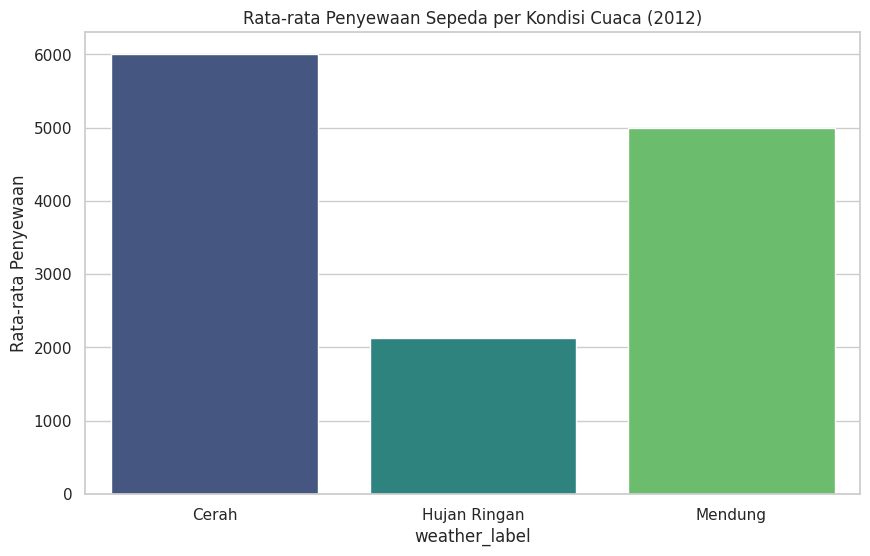

In [13]:
# Visualisasi 1: Pengaruh Cuaca
plt.figure(figsize=(10, 6))
sns.barplot(x='weather_label', y='cnt', data=weather_rentals, palette='viridis')
plt.title('Rata-rata Penyewaan Sepeda per Kondisi Cuaca (2012)')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

### Pertanyaan 2:

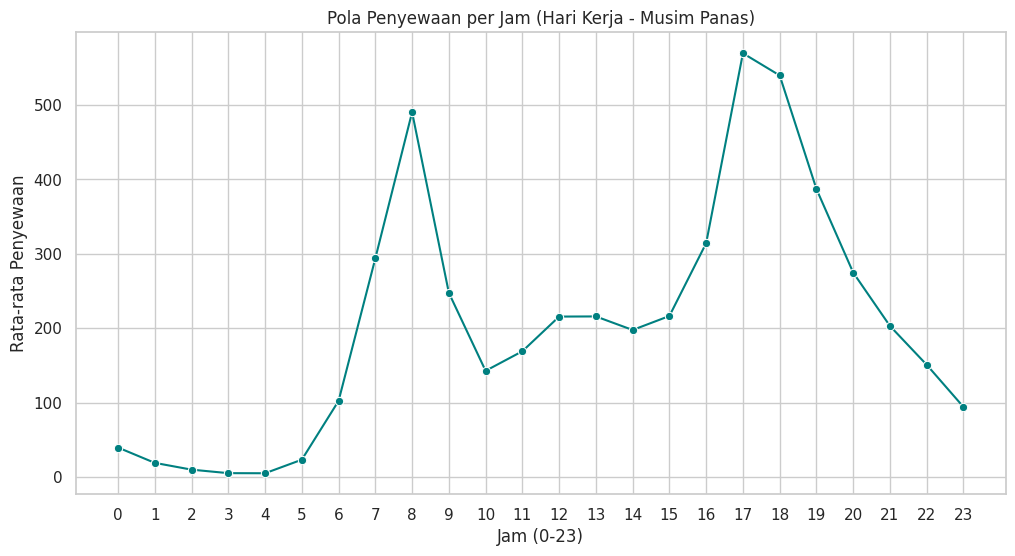

In [14]:
# Visualisasi 2: Jam Puncak
plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='cnt', data=hourly_rentals, marker='o', color='teal')
plt.xticks(range(0, 24))
plt.title('Pola Penyewaan per Jam (Hari Kerja - Musim Panas)')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:** (Opsional)
Berikut adalah insight dari Visualization & Explanatory Analysis tersebut:
- Pengaruh Signifikan Cuaca: Kondisi cuaca Cerah (Clear) merupakan kontributor terbesar terhadap jumlah penyewaan sepeda. Terlihat penurunan yang sangat drastis (lebih dari 50%) ketika cuaca berubah menjadi Hujan Ringan (Light Rain). Hal ini menunjukkan bahwa kenyamanan dan faktor keselamatan di jalan sangat memengaruhi keputusan pengguna.

- Ketidakhadiran Data Cuaca Ekstrem: Pada grafik batang, hampir tidak terlihat aktivitas pada kategori cuaca ekstrem. Ini mengindikasikan bahwa pada kondisi cuaca buruk yang parah, operasional penyewaan sepeda berhenti total atau tidak ada pengguna yang berani mengambil risiko.

- Karakteristik Pengguna Komuter: Tren pada jam kerja musim panas menunjukkan pola bimodal (dua puncak) yang sangat jelas. Puncak pertama terjadi pada pukul 08.00 dan puncak kedua pada pukul 17.00 - 18:00. Ini mengonfirmasi bahwa target pasar utama layanan ini adalah para pekerja atau pelajar yang menggunakan sepeda untuk transportasi rutin.

- Stabilitas Aktivitas Siang Hari: Meskipun terjadi penurunan setelah jam sibuk pagi, jumlah penyewaan pada siang hari (pukul 10.00 hingga 15.00) tetap berada di level yang stabil. Ini menandakan adanya penggunaan sepeda untuk keperluan non-komuter, seperti kurir atau aktivitas rekreasi singkat saat musim panas.

- Potensi Operasional di Malam Hari: Tren penyewaan terlihat tidak langsung anjlok setelah jam pulang kerja, melainkan menurun secara landai hingga pukul 21.00. Hal ini dipengaruhi oleh durasi siang hari yang lebih panjang pada musim panas, memberikan peluang bagi perusahaan untuk tetap melayani pengguna hingga malam hari.

## Analisis Lanjutan (Opsional)

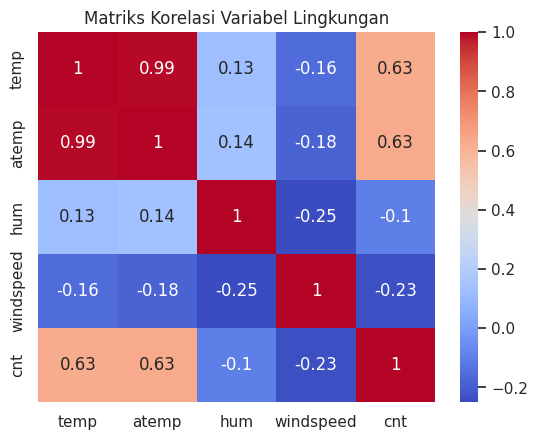

In [15]:
# Kode pendukung analisis lanjutan (opsional)
correlation_matrix = day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriks Korelasi Variabel Lingkungan')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis data tahun 2012 yang telah saya lakukan, maka dapat disimpulkan:
- Dominasi Cuaca Cerah: Kondisi cuaca Cerah merupakan pendorong utama performa bisnis. Pada kondisi ini, rata-rata jumlah penyewaan sepeda mencapai titik tertinggi dibandingkan kondisi cuaca lainnya. Hal ini menunjukkan bahwa cuaca cerah adalah "waktu emas" bagi operasional penyewaan sepeda.

- Penurunan Drastis Akibat Hujan: Terjadi perbedaan volume penyewaan yang sangat signifikan saat cuaca berubah. Berdasarkan grafik batang yang Anda buat, penyewaan pada kondisi Hujan Ringan mengalami penurunan lebih dari 50-60% dibandingkan saat cuaca cerah.

- Sensitivitas Pengguna: Perbedaan yang besar ini mengindikasikan bahwa pengguna sepeda (baik tipe casual maupun registered) sangat sensitif terhadap faktor kenyamanan dan keamanan. Hujan bukan hanya sekadar hambatan kecil, melainkan faktor utama yang menghentikan niat orang untuk bersepeda.

- Kondisi Ekstrem: Hampir tidak ada data penyewaan pada kondisi cuaca ekstrem (seperti badai atau hujan lebat yang parah), yang menandakan bahwa pada titik tersebut, mobilitas menggunakan sepeda dianggap tidak memungkinkan atau operasional mungkin dihentikan demi keselamatan.
- **Conclusion pertanyaan 2:** Berdasarkan analisis data terhadap puncak waktu penyewaan sepeda di satu hari kerja yang telah saya lakukan, maka dapat disimpulkan:
- Puncak Tertinggi: Penyewaan sepeda mencapai titik tertinggi pada pukul 17:00 dan 18:00.

- Puncak Pagi: Terdapat puncak kedua yang sangat signifikan pada pukul 08:00.

- Pola Utama: Tren ini menunjukkan pola "Double Peak" yang sangat khas untuk mobilitas komuter (pekerja dan pelajar).


**Rekomendasi Action Item:**

**1. Operasional & Manajemen Armada**
- Strategi Rebalancing Terjadwal: Mengatur ulang posisi unit sepeda agar tersedia maksimal di area residensial pada pukul 07:00 dan di area perkantoran/pusat bisnis pada pukul 16:00 - 17:00.

- Optimalisasi Waktu Maintenance: Menjadwalkan pengecekan teknis dan pembersihan sepeda pada jam rendah trafik, yaitu antara pukul 10:00 hingga 14:00, guna menjamin ketersediaan unit di jam sibuk pagi dan sore.

- Kesiagaan Pasca-Hujan: Menyiapkan tim lapangan untuk membersihkan unit (terutama bagian sadel dan rem) segera setelah hujan reda, agar pengguna merasa nyaman dan aman saat permintaan kembali naik.

**2. Strategi Pemasaran & Harga**
- Insentif Cuaca Buruk (Rainy Day Promo): Mengingat penurunan penyewaan mencapai lebih dari 50% saat hujan, perusahaan dapat memberikan promo otomatis berupa diskon atau poin ganda saat cuaca sedang tidak mendukung untuk menjaga volume transaksi.

- Paket Langganan Komuter Musim Panas: Meluncurkan paket harga khusus yang kompetitif untuk bulan-bulan musim panas, menargetkan pengguna yang melakukan perjalanan rutin di jam 8 pagi dan 5 sore.

- Fasilitas Pendukung: Menyediakan perlengkapan tambahan seperti jas hujan sekali pakai atau pelindung kursi sepeda tahan air di stasiun-stasiun besar untuk menarik minat pengguna saat kondisi cuaca mendung.

**3. Pengembangan Fitur Aplikasi**
- Notifikasi Cuaca Real-time: Mengintegrasikan prakiraan cuaca ke dalam aplikasi untuk memberi tahu pengguna waktu terbaik untuk bersepeda sebelum hujan turun.

- Informasi Ketersediaan Unit: Memperbarui data ketersediaan sepeda secara real-time di titik-titik puncak jam sibuk agar pengguna tidak kecewa saat sampai di stasiun tujuan.

- Sistem Reward Off-Peak: Memberikan insentif kecil bagi pengguna yang menyewa di jam siang hari (jam tidak sibuk) untuk meningkatkan utilitas sepeda secara merata di sepanjang hari.

**4. Customer Experience & Loyalitas**
- Tips Keamanan & Kenyamanan: Mengirimkan konten edukasi melalui aplikasi mengenai cara bersepeda yang aman saat suhu tinggi di musim panas (hidrasi) atau saat jalanan licin setelah hujan.

- Survei Kepuasan Musiman: Melakukan riset singkat untuk mengetahui rute baru mana yang paling diinginkan pengguna, terutama bagi mereka yang menggunakan sepeda sebagai moda transportasi utama menuju kantor.

In [16]:
import pandas as pd

# 1. Load data mentah (Pastikan hour.csv ada di folder yang sama)
df = pd.read_csv("hour.csv")

def create_main_data(df):
    # --- TAHAP CLEANING ---
    # Memastikan format tanggal benar
    df['dteday'] = pd.to_datetime(df['dteday'])

    # Mapping label (yr, season, weather) agar datanya deskriptif
    df['yr_label'] = df['yr'].map({0: '2011', 1: '2012'})

    df['season_label'] = df['season'].map({
        1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
    })

    df['weather_label'] = df['weathersit'].map({
        1: 'Clear',
        2: 'Misty/Cloudy',
        3: 'Light Rain/Snow',
        4: 'Heavy Rain'
    })

    # Mapping Nama Hari
    df['day_name'] = df['dteday'].dt.day_name()

    # --- TAHAP DENORMALISASI ---
    # Mengembalikan nilai ke satuan aslinya sesuai dokumentasi dataset
    df['temp_celsius'] = df['temp'] * 41
    df['atemp_celsius'] = df['atemp'] * 50
    df['hum_percent'] = df['hum'] * 100
    df['windspeed_kmph'] = df['windspeed'] * 67

    # --- TAHAP SELEKSI KOLOM ---
    # Memilih kolom-kolom yang hanya dibutuhkan untuk dashboard agar file lebih ringan
    main_columns = [
        'dteday', 'hr', 'yr_label', 'season_label', 'weather_label',
        'workingday', 'day_name', 'temp_celsius', 'hum_percent',
        'windspeed_kmph', 'casual', 'registered', 'cnt'
    ]

    return df[main_columns]

# Eksekusi
main_data = create_main_data(df)

# Simpan ke CSV
main_data.to_csv("main_data.csv", index=False)

print("Berhasil! File 'main_data.csv' telah dibuat.")
print(main_data.head())

Berhasil! File 'main_data.csv' telah dibuat.
      dteday  hr yr_label season_label weather_label  workingday  day_name  \
0 2011-01-01   0     2011       Spring         Clear           0  Saturday   
1 2011-01-01   1     2011       Spring         Clear           0  Saturday   
2 2011-01-01   2     2011       Spring         Clear           0  Saturday   
3 2011-01-01   3     2011       Spring         Clear           0  Saturday   
4 2011-01-01   4     2011       Spring         Clear           0  Saturday   

   temp_celsius  hum_percent  windspeed_kmph  casual  registered  cnt  
0          9.84         81.0             0.0       3          13   16  
1          9.02         80.0             0.0       8          32   40  
2          9.02         80.0             0.0       5          27   32  
3          9.84         75.0             0.0       3          10   13  
4          9.84         75.0             0.0       0           1    1  
